# Model Team B – XGBoost Ensemble Baseline + Extensions

This notebook implements the **Model Team B** workflow for recession forecasting using the same transformed quarterly dataset as Model Team A:

1. XGBoost classifiers for **1Q, 2Q, 3Q ahead**
2. Feature engineering with **lags, rolling averages, and regime dummies** (identical to Team A)
3. **SHAP-based feature importance** ranking (replaces mutual information)
4. **Hyperparameter tuning** via time-series-aware cross-validation
5. **Walk-forward validation** with expanding windows
6. ROC, calibration, and probability path plots
7. SHAP summary plots and feature contribution tables
8. **Elastic Net logistic regression** (L1+L2 blend)
9. **SMOTE + XGBoost** (oversampling fix for class imbalance)
10. **Stacking ensemble** (meta-learner over OOF predictions)
11. **Robustness across regimes** (pre-2000, 2000–2008, post-2008, post-2020)

Results are directly comparable to the logistic regression baselines from Model Team A.


# 1 – Load Libraries & Environment Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import statsmodels.api as sm
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_curve,
)
from sklearn.calibration import calibration_curve
warnings.filterwarnings("ignore")
shap.initjs()
print("Libraries loaded successfully.")
print("Note: requires imbalanced-learn — install with: pip install imbalanced-learn")

/opt/anaconda3/envs/ds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.
Note: requires imbalanced-learn — install with: pip install imbalanced-learn


# 2 – Data Ingestion & Preprocessing

## 2.1 – Load the Data

In [2]:
DATA_PATH = "DS_SOURCES_PIPELINE/master_dataset_transformed_after 1986.csv"
OUTDIR = "model_team_b_outputs"
os.makedirs(OUTDIR, exist_ok=True)
df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (145, 15)


,Date,USRECD,T10Y2Y,TEDRATE,BAA10Y,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,BAA10Y_missing,T10Y2Y_missing,FEDFUNDS_missing,UNRATE_d1,INDPRO_lgyoy,CPIAUCSL_lgyoy,FEDFUNDS_d1
0,1986-01-01,0.0,0.789333,1.012034,2.452667,0.0,0.0,0.0,0,0,0,0.000000,0.010821,0.030582,-0.276667
1,1986-04-01,0.0,0.620156,0.859048,2.672656,0.0,0.0,0.0,0,0,0,0.133333,0.004214,0.016647,-0.906667
2,1986-07-01,0.0,0.855781,0.766984,2.877031,0.0,0.0,0.0,0,0,0,-0.200000,0.009566,0.016544,-0.713333
3,1986-10-01,0.0,0.988226,0.808197,2.828065,0.0,0.0,0.0,0,0,0,-0.133333,0.015031,0.013366,0.060000
4,1987-01-01,0.0,0.844262,0.847705,2.466393,0.0,0.0,0.0,0,0,0,-0.233333,0.022378,0.020178,-0.046667


## 2.2 – Data Cleaning

Identical cleaning step to Model Team A: drop the unreliable TEDRATE series and redundant missing-indicator columns.

In [3]:
df = df.drop(columns=["BAA10Y_missing", "T10Y2Y_missing", "FEDFUNDS_missing", "TEDRATE"])
print(f"Cleaned shape: {df.shape}")
df.head()

Cleaned shape: (145, 11)


,Date,USRECD,T10Y2Y,BAA10Y,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,UNRATE_d1,INDPRO_lgyoy,CPIAUCSL_lgyoy,FEDFUNDS_d1
0,1986-01-01,0.0,0.789333,2.452667,0.0,0.0,0.0,0.000000,0.010821,0.030582,-0.276667
1,1986-04-01,0.0,0.620156,2.672656,0.0,0.0,0.0,0.133333,0.004214,0.016647,-0.906667
2,1986-07-01,0.0,0.855781,2.877031,0.0,0.0,0.0,-0.200000,0.009566,0.016544,-0.713333
3,1986-10-01,0.0,0.988226,2.828065,0.0,0.0,0.0,-0.133333,0.015031,0.013366,0.060000
4,1987-01-01,0.0,0.844262,2.466393,0.0,0.0,0.0,-0.233333,0.022378,0.020178,-0.046667


## 2.3 – Feature Engineering: Temporal Dynamics & Regime Shifts

Identical feature engineering to Model Team A to ensure a fair apples-to-apples comparison:
- **Lags (1–3 quarters)** on six core macro signals
- **Rolling averages (3Q and 6Q windows)** to smooth noise
- **Structural break dummies** for post-2008 and post-2020 regime shifts

In [4]:
signal_cols = [
    "T10Y2Y", "BAA10Y",
    "UNRATE_d1", "INDPRO_lgyoy", "CPIAUCSL_lgyoy", "FEDFUNDS_d1"
]
edf = df.copy()
for col in signal_cols:
    for lag in [1, 2, 3]:
        edf[f"{col}_lag{lag}"] = edf[col].shift(lag)
    for win in [3, 6]:
        edf[f"{col}_roll{win}"] = edf[col].rolling(win, min_periods=win).mean()
edf["post_2008"] = (edf["Date"] >= pd.Timestamp("2008-01-01")).astype(int)
edf["post_2020"] = (edf["Date"] >= pd.Timestamp("2020-01-01")).astype(int)
target_cols = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]
feature_cols = [c for c in edf.columns if c not in ["Date", "USRECD"] + target_cols]
print(f"Rows: {len(edf)}")
print(f"Engineered features: {len(feature_cols)}")
print(feature_cols[:10])

Rows: 145
Engineered features: 38
['T10Y2Y', 'BAA10Y', 'UNRATE_d1', 'INDPRO_lgyoy', 'CPIAUCSL_lgyoy', 'FEDFUNDS_d1', 'T10Y2Y_lag1', 'T10Y2Y_lag2', 'T10Y2Y_lag3', 'T10Y2Y_roll3']


# 3 – Shared Utilities

In [5]:
horizons = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]

def prep_dataset(horizon: str):
    data = edf.dropna(subset=feature_cols + [horizon]).copy().reset_index(drop=True)
    X = data[feature_cols]
    y = data[horizon].astype(int)
    return data, X, y

def expanding_splits(n: int, initial: int = 60, test: int = 8, step: int = 8):
    """Identical split logic to Model Team A for comparability."""
    splits = []
    start = initial
    while start + test <= n:
        splits.append((np.arange(start), np.arange(start, start + test)))
        start += step
    return splits

def record_metrics(all_results, horizon, model_name, ys, preds):
    """Append a standard metrics row to all_results."""
    all_results.append({
        "horizon":           horizon.replace("Target_", "").replace("_ahead", ""),
        "model":             model_name,
        "oof_n":             len(ys),
        "positives":         int(ys.sum()),
        "auc":               roc_auc_score(ys, preds),
        "average_precision": average_precision_score(ys, preds),
        "brier":             brier_score_loss(ys, preds),
        "log_loss":          log_loss(ys, preds, labels=[0, 1]),
    })

# Global stores
all_results       = []
oof_store         = {}
shap_store        = {}
best_params_store = {}
print("Utilities defined.")

Utilities defined.


# 4 – XGBoost Models (Original)

## 4.1 – Hyperparameter Grid & Inner CV

In [6]:
PARAM_GRID = list(ParameterGrid({
    "n_estimators":     [200, 400],
    "max_depth":        [2, 3],
    "learning_rate":    [0.05, 0.10],
    "subsample":        [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha":        [0.1, 1.0],
    "reg_lambda":       [1.0, 5.0],
}))
print(f"Hyperparameter combinations: {len(PARAM_GRID)}")

def inner_cv_best_params(Xtr, ytr, param_grid, n_splits=3):
    n = len(Xtr)
    inner_initial = max(20, n // (n_splits + 1))
    inner_test    = max(5, (n - inner_initial) // n_splits)
    best_score, best_params = -np.inf, param_grid[0]
    for params in param_grid:
        scores = []
        start  = inner_initial
        while start + inner_test <= n:
            itr = np.arange(start)
            ite = np.arange(start, start + inner_test)
            start += inner_test
            if len(np.unique(ytr[itr])) < 2 or len(np.unique(ytr[ite])) < 2:
                continue
            spw = (ytr[itr] == 0).sum() / max((ytr[itr] == 1).sum(), 1)
            clf = XGBClassifier(
                **params, scale_pos_weight=spw,
                use_label_encoder=False, eval_metric="logloss",
                random_state=42, n_jobs=-1, verbosity=0,
            )
            clf.fit(Xtr[itr], ytr[itr])
            scores.append(roc_auc_score(ytr[ite], clf.predict_proba(Xtr[ite])[:, 1]))
        if scores and np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params
    return best_params

Hyperparameter combinations: 32


## 4.2 – Walk-Forward Validation (XGBoost Tuned & Default)

In [7]:
for horizon in horizons:
    print(f"\n{'='*55}")
    print(f"XGBoost — {horizon}")
    print(f"{'='*55}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    for model_name, tune in [("xgb_tuned", True), ("xgb_default", False)]:
        preds, ys, dates = [], [], []
        shap_vals_list, shap_X_list, fold_params = [], [], []
        for tr, te in splits:
            Xtr_raw, Xte_raw = X_np[tr], X_np[te]
            ytr, yte = y_np[tr], y_np[te]
            imp = SimpleImputer(strategy="median")
            Xtr_imp = imp.fit_transform(Xtr_raw)
            Xte_imp = imp.transform(Xte_raw)
            spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
            params = (
                inner_cv_best_params(Xtr_imp, ytr, PARAM_GRID) if tune
                else {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05,
                      "subsample": 0.8, "colsample_bytree": 0.8,
                      "reg_alpha": 0.5, "reg_lambda": 2.0}
            )
            fold_params.append(params)
            clf = XGBClassifier(
                **params, scale_pos_weight=spw,
                use_label_encoder=False, eval_metric="logloss",
                random_state=42, n_jobs=-1, verbosity=0,
            )
            clf.fit(Xtr_imp, ytr)
            p = clf.predict_proba(Xte_imp)[:, 1]
            preds.extend(p)
            ys.extend(yte.tolist())
            dates.extend(data.iloc[te]["Date"].tolist())
            explainer = shap.TreeExplainer(clf)
            sv = explainer.shap_values(Xte_imp)
            if isinstance(sv, list):
                sv = sv[1]
            shap_vals_list.append(sv)
            shap_X_list.append(Xte_imp)
        ys, preds = np.array(ys), np.array(preds)
        record_metrics(all_results, horizon, model_name, ys, preds)
        oof_store[(horizon, model_name)] = pd.DataFrame(
            {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
        ).sort_values("Date").reset_index(drop=True)
        shap_store[(horizon, model_name)] = {
            "values": np.vstack(shap_vals_list),
            "X": np.vstack(shap_X_list),
        }
        best_params_store[(horizon, model_name)] = fold_params
        auc_val = all_results[-1]["auc"]
        ap_val  = all_results[-1]["average_precision"]
        print(f"  {model_name:20s}  AUC={auc_val:.3f}  AP={ap_val:.3f}")
print("\nXGBoost walk-forward complete.")


XGBoost — Target_1Q_ahead
  xgb_tuned             AUC=0.847  AP=0.393
  xgb_default           AUC=0.859  AP=0.391

XGBoost — Target_2Q_ahead
  xgb_tuned             AUC=0.849  AP=0.383
  xgb_default           AUC=0.826  AP=0.380

XGBoost — Target_3Q_ahead
  xgb_tuned             AUC=0.868  AP=0.515
  xgb_default           AUC=0.802  AP=0.475

XGBoost walk-forward complete.


# 5 – Elastic Net Logistic Regression

Elastic Net blends L1 (sparsity) and L2 (shrinkage) penalties via the `l1_ratio` hyperparameter:
- `l1_ratio=1.0` → pure L1 (identical to Sparse L1 from Team A)
- `l1_ratio=0.0` → pure L2
- `l1_ratio=0.5` → equal blend

**Why this can beat Sparse L1:** Yield-curve lags are highly correlated (T10Y2Y_lag1, T10Y2Y_lag2, T10Y2Y_lag3). Pure L1 arbitrarily zeroes all but one of a correlated group. Elastic Net retains the whole group and distributes weight across them, often improving predictive stability and average precision.

In [8]:
ENET_GRID = list(ParameterGrid({
    "C":        [0.1, 0.25, 0.5, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8],
}))

def inner_cv_logreg(Xtr, ytr, param_grid, penalty="elasticnet", n_splits=3):
    """Inner expanding CV for any sklearn LogisticRegression variant."""
    n = len(Xtr)
    inner_initial = max(20, n // (n_splits + 1))
    inner_test    = max(5, (n - inner_initial) // n_splits)
    best_score, best_params = -np.inf, param_grid[0]
    for params in param_grid:
        scores = []
        start  = inner_initial
        while start + inner_test <= n:
            itr = np.arange(start)
            ite = np.arange(start, start + inner_test)
            start += inner_test
            if len(np.unique(ytr[itr])) < 2 or len(np.unique(ytr[ite])) < 2:
                continue
            clf = LogisticRegression(
                penalty=penalty, solver="saga",
                class_weight="balanced", max_iter=5000,
                **params, random_state=42
            )
            clf.fit(Xtr[itr], ytr[itr])
            scores.append(roc_auc_score(ytr[ite], clf.predict_proba(Xtr[ite])[:, 1]))
        if scores and np.mean(scores) > best_score:
            best_score, best_params = np.mean(scores), params
    return best_params

for horizon in horizons:
    print(f"\nElastic Net — {horizon}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    preds, ys, dates = [], [], []
    for tr, te in splits:
        Xtr_raw, Xte_raw = X_np[tr], X_np[te]
        ytr, yte = y_np[tr], y_np[te]
        imp    = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        Xtr_s  = scaler.fit_transform(imp.fit_transform(Xtr_raw))
        Xte_s  = scaler.transform(imp.transform(Xte_raw))
        best_p = inner_cv_logreg(Xtr_s, ytr, ENET_GRID, penalty="elasticnet")
        clf = LogisticRegression(
            penalty="elasticnet", solver="saga",
            class_weight="balanced", max_iter=5000,
            **best_p, random_state=42
        )
        clf.fit(Xtr_s, ytr)
        p = clf.predict_proba(Xte_s)[:, 1]
        preds.extend(p)
        ys.extend(yte.tolist())
        dates.extend(data.iloc[te]["Date"].tolist())
    ys, preds = np.array(ys), np.array(preds)
    record_metrics(all_results, horizon, "elastic_net", ys, preds)
    oof_store[(horizon, "elastic_net")] = pd.DataFrame(
        {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
    ).sort_values("Date").reset_index(drop=True)
    auc_val = all_results[-1]["auc"]
    ap_val  = all_results[-1]["average_precision"]
    print(f"  elastic_net           AUC={auc_val:.3f}  AP={ap_val:.3f}")
print("\nElastic Net walk-forward complete.")


Elastic Net — Target_1Q_ahead
  elastic_net           AUC=0.967  AP=0.679

Elastic Net — Target_2Q_ahead
  elastic_net           AUC=0.950  AP=0.574

Elastic Net — Target_3Q_ahead
  elastic_net           AUC=0.835  AP=0.351

Elastic Net walk-forward complete.


# 6 – SMOTE + XGBoost

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic recession observations by interpolating between real ones in feature space. It is applied **only inside training folds** — never on the test fold — to avoid data leakage.

**Why SMOTE can help XGBoost specifically:** `scale_pos_weight` re-weights the gradient but does not change the feature distribution seen by the trees. SMOTE actually populates the minority-class region with new training points, giving tree splits more information about the recession decision boundary.

**Caution:** SMOTE assumes local linear interpolation. If recession onset is driven by a non-linear joint threshold (e.g. yield curve AND unemployment together), SMOTE may generate unrealistic training examples. Inspect SHAP values after to confirm key features are unchanged.

In [9]:
for horizon in horizons:
    print(f"\nSMOTE + XGBoost — {horizon}")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data))
    X_np, y_np = X.values, y.values
    preds, ys, dates = [], [], []
    for tr, te in splits:
        Xtr_raw, Xte_raw = X_np[tr], X_np[te]
        ytr, yte = y_np[tr], y_np[te]
        imp     = SimpleImputer(strategy="median")
        Xtr_imp = imp.fit_transform(Xtr_raw)
        Xte_imp = imp.transform(Xte_raw)
        n_minority  = int(ytr.sum())
        k_neighbors = min(5, max(1, n_minority - 1))
        if n_minority >= 2:
            sm_sampler  = SMOTE(k_neighbors=k_neighbors, random_state=42)
            Xtr_res, ytr_res = sm_sampler.fit_resample(Xtr_imp, ytr)
        else:
            Xtr_res, ytr_res = Xtr_imp, ytr
        clf = XGBClassifier(
            n_estimators=300, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.5, reg_lambda=2.0,
            scale_pos_weight=1,
            use_label_encoder=False, eval_metric="logloss",
            random_state=42, n_jobs=-1, verbosity=0,
        )
        clf.fit(Xtr_res, ytr_res)
        p = clf.predict_proba(Xte_imp)[:, 1]
        preds.extend(p)
        ys.extend(yte.tolist())
        dates.extend(data.iloc[te]["Date"].tolist())
    ys, preds = np.array(ys), np.array(preds)
    record_metrics(all_results, horizon, "smote_xgb", ys, preds)
    oof_store[(horizon, "smote_xgb")] = pd.DataFrame(
        {"Date": pd.to_datetime(dates), "y_true": ys, "y_prob": preds}
    ).sort_values("Date").reset_index(drop=True)
    auc_val = all_results[-1]["auc"]
    ap_val  = all_results[-1]["average_precision"]
    print(f"  smote_xgb             AUC={auc_val:.3f}  AP={ap_val:.3f}")
print("\nSMOTE + XGBoost walk-forward complete.")


SMOTE + XGBoost — Target_1Q_ahead
  smote_xgb             AUC=0.875  AP=0.428

SMOTE + XGBoost — Target_2Q_ahead
  smote_xgb             AUC=0.826  AP=0.346

SMOTE + XGBoost — Target_3Q_ahead
  smote_xgb             AUC=0.847  AP=0.369

SMOTE + XGBoost walk-forward complete.


# 7 – Stacking Ensemble

The stacking ensemble trains a **meta-learner** (L2 logistic regression) on the OOF predictions from the best base models. This works because:
1. Sparse L1 and XGBoost Tuned make **different kinds of errors** — the linear model captures smooth yield-curve trends well; XGBoost captures non-linear threshold effects
2. The meta-learner learns how much to trust each base model and can weight them differently per horizon
3. OOF predictions are used as training features for the meta-learner, preventing data leakage

**Base models included in stack:**
- `xgb_tuned` — best single XGBoost model
- `elastic_net` — best linear model from this notebook
- `smote_xgb` — SMOTE-corrected XGBoost

If `model_team_a_outputs/` is present, Team A's Sparse L1 OOF predictions are loaded and added automatically.

In [10]:
TEAM_A_OOF_DIR = "model_team_a_outputs"
team_a_available = os.path.exists(TEAM_A_OOF_DIR)
if team_a_available:
    print("Team A outputs found — Sparse L1 will be included in the stack.")
else:
    print("Team A outputs not found — stacking without Sparse L1 base model.")
    print("Run Model Team A notebook first to include it.")

BASE_MODELS = ["xgb_tuned", "elastic_net", "smote_xgb"]

for horizon in horizons:
    print(f"\nStacking Ensemble — {horizon}")
    data, X, y = prep_dataset(horizon)
    oof_frames = {}
    for bm in BASE_MODELS:
        frame = oof_store[(horizon, bm)].set_index("Date")["y_prob"]
        oof_frames[bm] = frame
    if team_a_available:
        path = os.path.join(TEAM_A_OOF_DIR, f"{horizon}_sparse_l1_oof.csv")
        if os.path.exists(path):
            ta_oof = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["y_prob"]
            oof_frames["sparse_l1"] = ta_oof
    meta_df = pd.DataFrame(oof_frames).dropna()
    true_series = oof_store[(horizon, "xgb_tuned")].set_index("Date")["y_true"]
    meta_df["y_true"] = true_series.reindex(meta_df.index)
    meta_df = meta_df.dropna()
    dates_meta = meta_df.index
    base_cols  = [c for c in meta_df.columns if c != "y_true"]
    X_meta     = meta_df[base_cols].values
    y_meta     = meta_df["y_true"].values.astype(int)
    splits_meta = expanding_splits(len(meta_df), initial=20, test=8, step=8)
    meta_preds, meta_ys, meta_dates = [], [], []
    for tr, te in splits_meta:
        Xm_tr, Xm_te = X_meta[tr], X_meta[te]
        ym_tr, ym_te = y_meta[tr], y_meta[te]
        if len(np.unique(ym_tr)) < 2:
            p = Xm_te.mean(axis=1)
        else:
            meta_clf = LogisticRegression(
                penalty="l2", C=1.0, class_weight="balanced",
                solver="lbfgs", max_iter=2000, random_state=42
            )
            meta_clf.fit(Xm_tr, ym_tr)
            p = meta_clf.predict_proba(Xm_te)[:, 1]
        meta_preds.extend(p)
        meta_ys.extend(ym_te.tolist())
        meta_dates.extend(dates_meta[te].tolist())
    meta_ys    = np.array(meta_ys)
    meta_preds = np.array(meta_preds)
    record_metrics(all_results, horizon, "stack_ensemble", meta_ys, meta_preds)
    oof_store[(horizon, "stack_ensemble")] = pd.DataFrame({
        "Date":   pd.to_datetime(meta_dates),
        "y_true": meta_ys,
        "y_prob": meta_preds,
    }).sort_values("Date").reset_index(drop=True)
    auc_val = all_results[-1]["auc"]
    ap_val  = all_results[-1]["average_precision"]
    print(f"  stack_ensemble        AUC={auc_val:.3f}  AP={ap_val:.3f}")
    print(f"  (base models used: {base_cols})")
print("\nStacking Ensemble walk-forward complete.")

Team A outputs not found — stacking without Sparse L1 base model.
Run Model Team A notebook first to include it.

Stacking Ensemble — Target_1Q_ahead
  stack_ensemble        AUC=0.938  AP=0.607
  (base models used: ['xgb_tuned', 'elastic_net', 'smote_xgb'])

Stacking Ensemble — Target_2Q_ahead
  stack_ensemble        AUC=0.786  AP=0.384
  (base models used: ['xgb_tuned', 'elastic_net', 'smote_xgb'])

Stacking Ensemble — Target_3Q_ahead
  stack_ensemble        AUC=0.490  AP=0.408
  (base models used: ['xgb_tuned', 'elastic_net', 'smote_xgb'])

Stacking Ensemble walk-forward complete.


# 8 – Evaluation & Diagnostics

## 8.1 – Full Metrics Summary

In [11]:
results_df = pd.DataFrame(all_results).sort_values(["horizon", "model"]).reset_index(drop=True)
print("Out-of-Sample Performance Metrics — All Models:")
display(results_df.round(4))
results_df.to_csv(os.path.join(OUTDIR, "xgb_model_comparison.csv"), index=False)

Out-of-Sample Performance Metrics — All Models:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,elastic_net,80,8,0.9670,0.6787,0.0587,0.4532
1,1Q,smote_xgb,80,8,0.8750,0.4279,0.0827,0.3207
2,1Q,stack_ensemble,56,8,0.9375,0.6072,0.0999,0.3775
3,1Q,xgb_default,80,8,0.8594,0.3905,0.0952,0.3426
4,1Q,xgb_tuned,80,8,0.8472,0.3926,0.0903,0.3158
5,2Q,elastic_net,80,8,0.9497,0.5736,0.0778,0.3062
6,2Q,smote_xgb,80,8,0.8264,0.3463,0.0898,0.3297
7,2Q,stack_ensemble,56,8,0.7865,0.3838,0.1471,0.4995
8,2Q,xgb_default,80,8,0.8264,0.3798,0.0923,0.3366
9,2Q,xgb_tuned,80,8,0.8490,0.3830,0.0914,0.3286


## 8.2 – Best Model per Horizon

In [12]:
best_per_horizon = (
    results_df
    .sort_values("auc", ascending=False)
    .groupby("horizon")
    .first()
    .reset_index()[["horizon", "model", "auc", "average_precision", "brier", "log_loss"]]
)
print("Best model per horizon (by AUC):")
display(best_per_horizon.round(4))

Best model per horizon (by AUC):


,horizon,model,auc,average_precision,brier,log_loss
0,1Q,elastic_net,0.9670,0.6787,0.0587,0.4532
1,2Q,elastic_net,0.9497,0.5736,0.0778,0.3062
2,3Q,xgb_tuned,0.8681,0.5145,0.0900,0.3335


## 8.3 – Pivoted Metrics Table

In [13]:
pivot = results_df.pivot_table(
    index="model",
    columns="horizon",
    values=["auc", "average_precision", "brier", "log_loss"],
).round(4)
print("Pivoted metrics table:")
display(pivot)
pivot.to_csv(os.path.join(OUTDIR, "xgb_metrics_pivoted.csv"))

Pivoted metrics table:


auc                 average_precision                  \
horizon             1Q      2Q      3Q                1Q      2Q      3Q   
model                                                                      
elastic_net     0.9670  0.9497  0.8351            0.6787  0.5736  0.3513   
smote_xgb       0.8750  0.8264  0.8472            0.4279  0.3463  0.3687   
stack_ensemble  0.9375  0.7865  0.4896            0.6072  0.3838  0.4082   
xgb_default     0.8594  0.8264  0.8021            0.3905  0.3798  0.4754   
xgb_tuned       0.8472  0.8490  0.8681            0.3926  0.3830  0.5145   

                 brier                 log_loss                  
horizon             1Q      2Q      3Q       1Q      2Q      3Q  
model                                                            
elastic_net     0.0587  0.0778  0.1046   0.4532  0.3062  0.3116  
smote_xgb       0.0827  0.0898  0.0913   0.3207  0.3297  0.3437  
stack_ensemble  0.0999  0.1471  0.1892   0.3775  0.4995  0.5742  
xgb_default     0.0952  0.0923  0.0901   0.3426  0.3366  0.3473  
xgb_tuned       0.0903  0.0914  0.0900   0.3158  0.3286  0.3335

## 8.4 – ROC, Calibration & Probability Path Plots

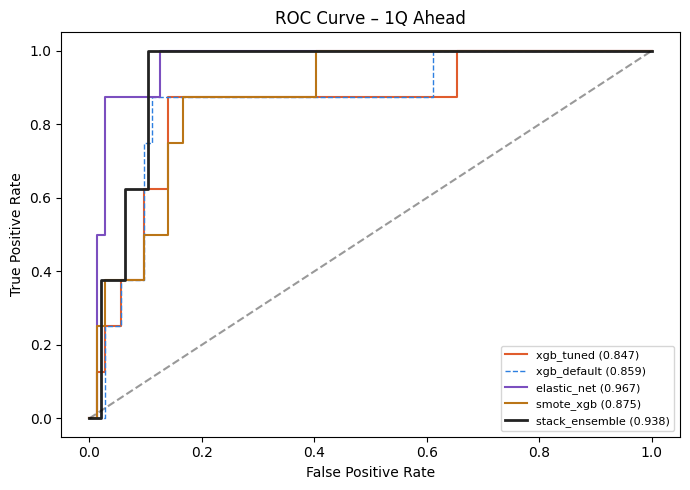

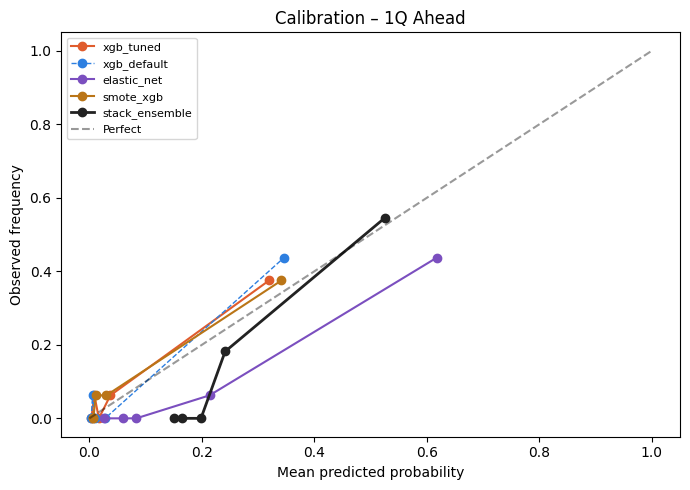

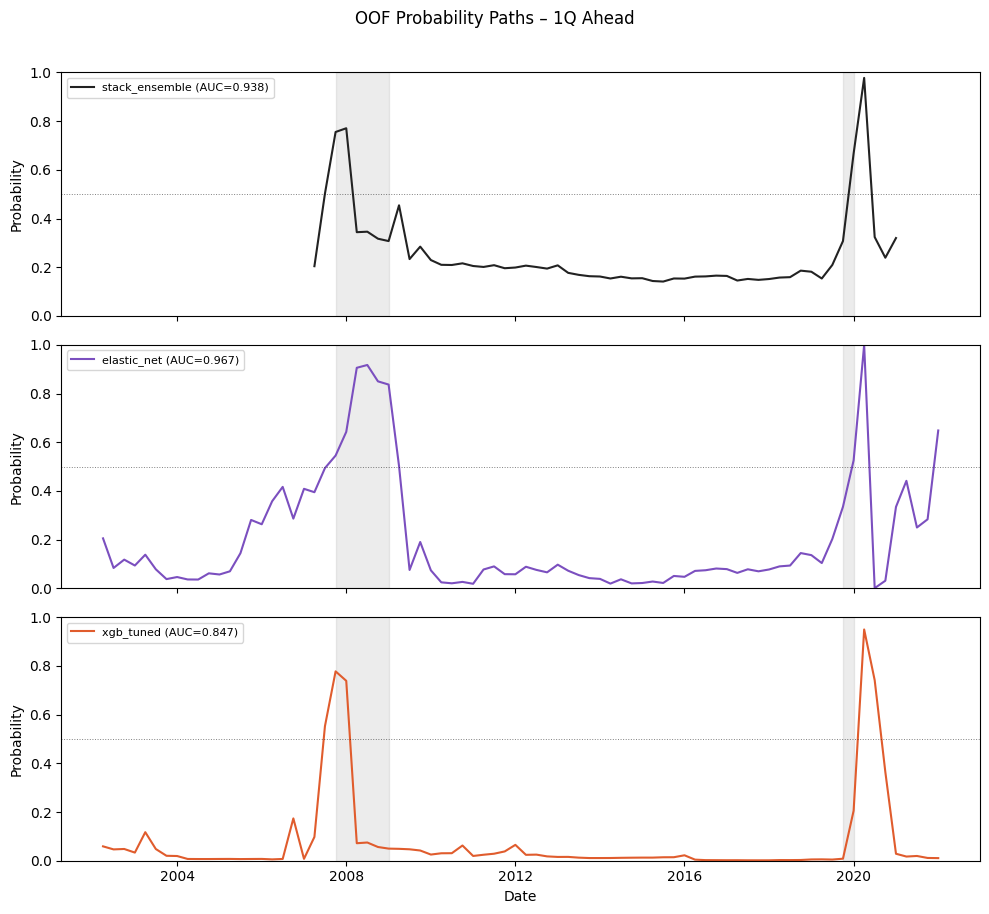

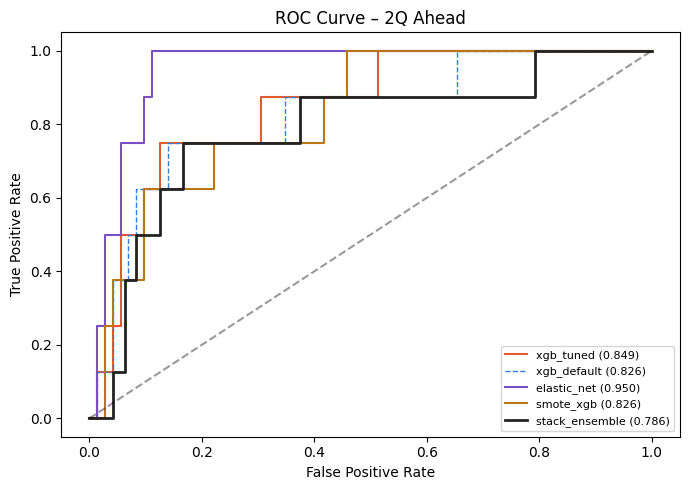

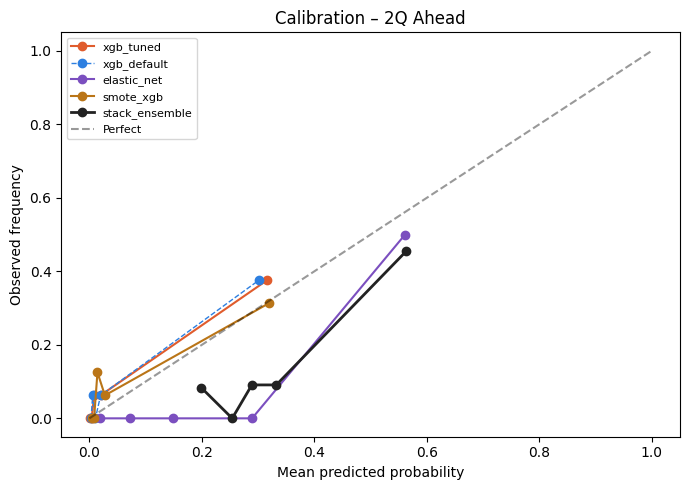

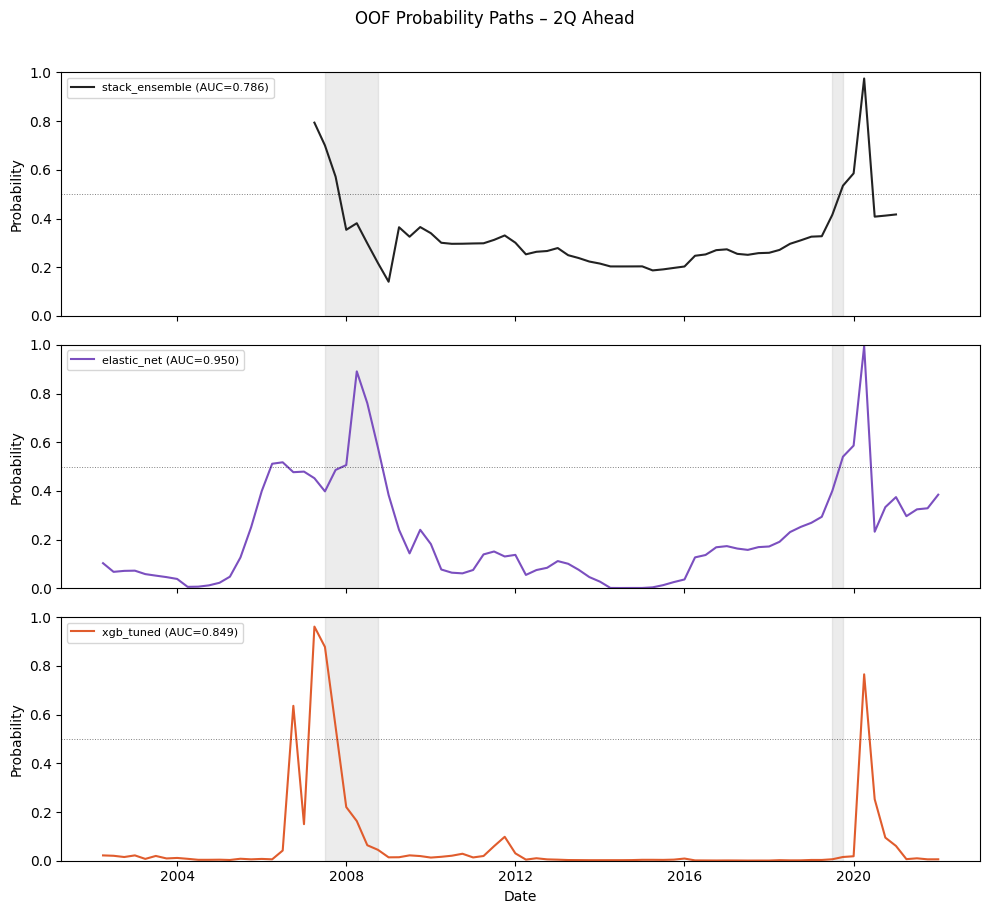

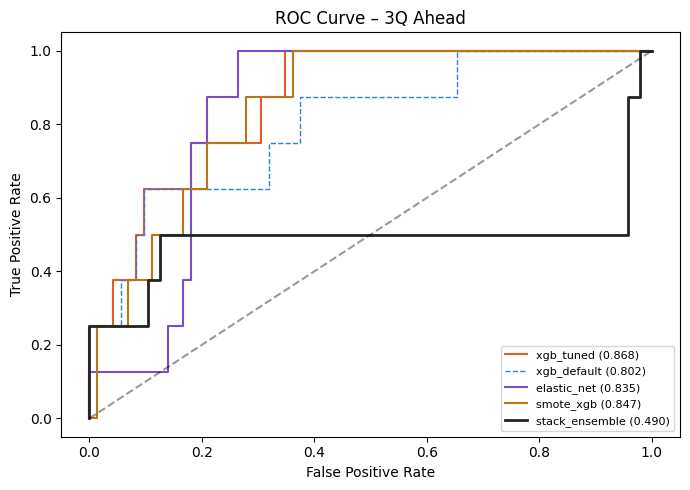

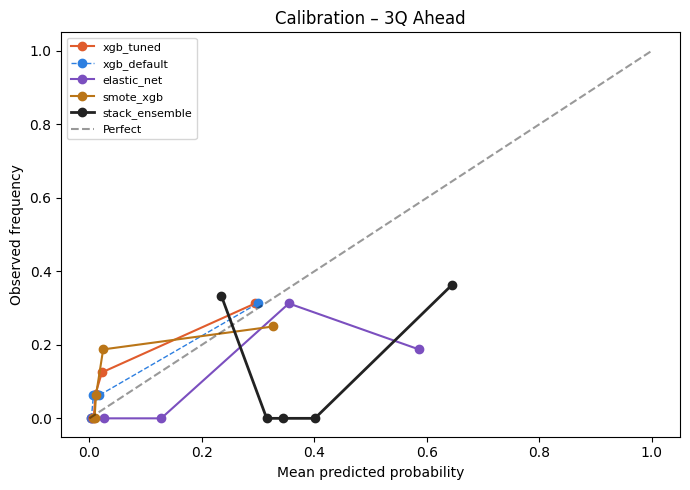

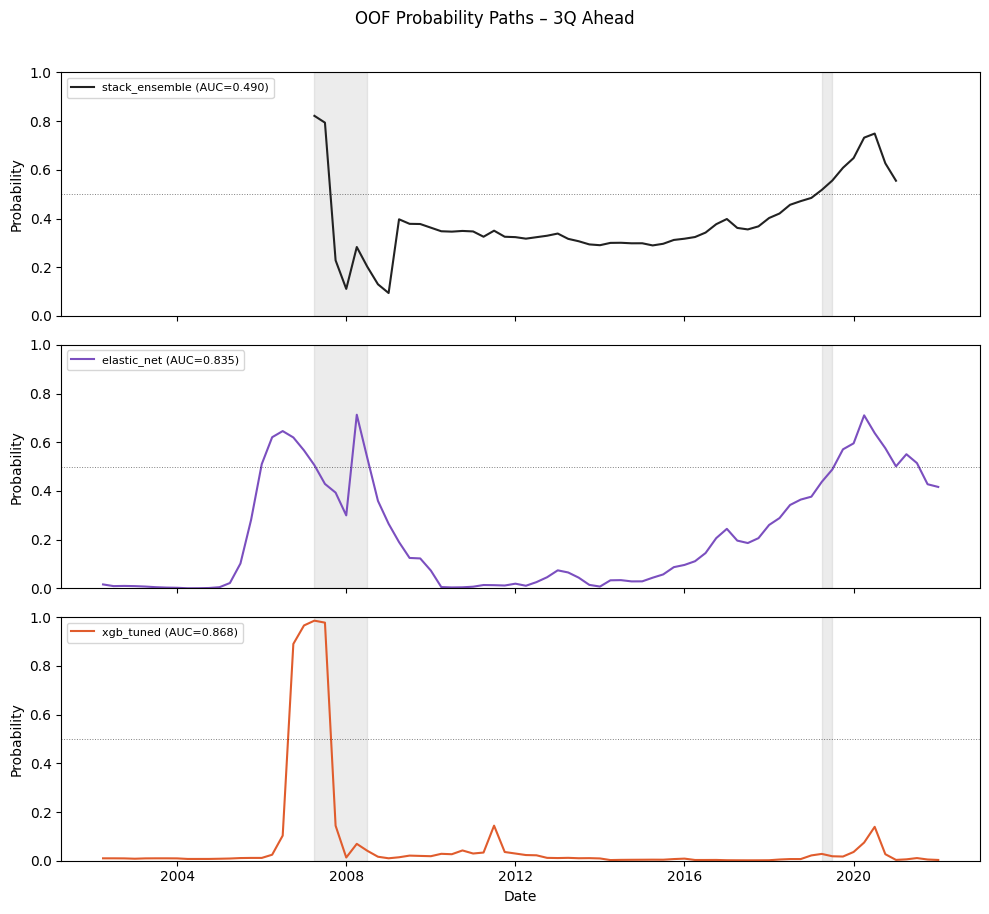

In [14]:
MODEL_STYLES = {
    "xgb_tuned":      {"color": "#e05c2d", "lw": 1.5, "ls": "-"},
    "xgb_default":    {"color": "#2d7fe0", "lw": 1.0, "ls": "--"},
    "elastic_net":    {"color": "#7B4FBF", "lw": 1.5, "ls": "-"},
    "smote_xgb":      {"color": "#BA7517", "lw": 1.5, "ls": "-"},
    "stack_ensemble": {"color": "#222222", "lw": 2.0, "ls": "-"},
}
plot_models = [m for m in MODEL_STYLES if any((h, m) in oof_store for h in horizons)]

for horizon in horizons:
    label = horizon.replace("Target_", "").replace("_ahead", "")
    plt.figure(figsize=(7, 5))
    for mname in plot_models:
        if (horizon, mname) not in oof_store:
            continue
        frame = oof_store[(horizon, mname)]
        fpr, tpr, _ = roc_curve(frame["y_true"], frame["y_prob"])
        auc_val = roc_auc_score(frame["y_true"], frame["y_prob"])
        s = MODEL_STYLES[mname]
        plt.plot(fpr, tpr, color=s["color"], lw=s["lw"], ls=s["ls"],
                 label=f"{mname} ({auc_val:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {label} Ahead")
    plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_roc_all.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(7, 5))
    for mname in plot_models:
        if (horizon, mname) not in oof_store:
            continue
        frame = oof_store[(horizon, mname)]
        prob_true, prob_pred = calibration_curve(
            frame["y_true"], frame["y_prob"], n_bins=5, strategy="quantile")
        s = MODEL_STYLES[mname]
        plt.plot(prob_pred, prob_true, marker="o",
                 color=s["color"], lw=s["lw"], ls=s["ls"], label=mname)
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration – {label} Ahead")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_calibration_all.png"), dpi=150)
    plt.show()

    highlight_models = ["stack_ensemble", "elastic_net", "xgb_tuned"]
    fig, axes = plt.subplots(len(highlight_models), 1,
                             figsize=(10, 3 * len(highlight_models)), sharex=True)
    for ax, mname in zip(axes, highlight_models):
        if (horizon, mname) not in oof_store:
            ax.set_visible(False)
            continue
        frame = oof_store[(horizon, mname)]
        s = MODEL_STYLES[mname]
        auc_val = roc_auc_score(frame["y_true"], frame["y_prob"])
        ax.plot(frame["Date"], frame["y_prob"], color=s["color"], lw=1.5,
                label=f"{mname} (AUC={auc_val:.3f})")
        ax.fill_between(frame["Date"], 0, 1, where=frame["y_true"].astype(bool),
                        alpha=0.15, color="grey", transform=ax.get_xaxis_transform())
        ax.axhline(0.5, color="black", ls=":", lw=0.7, alpha=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Probability")
        ax.legend(fontsize=8, loc="upper left")
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"OOF Probability Paths – {label} Ahead", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_probability_paths.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 8.5 – SHAP Feature Importance (XGBoost variants)

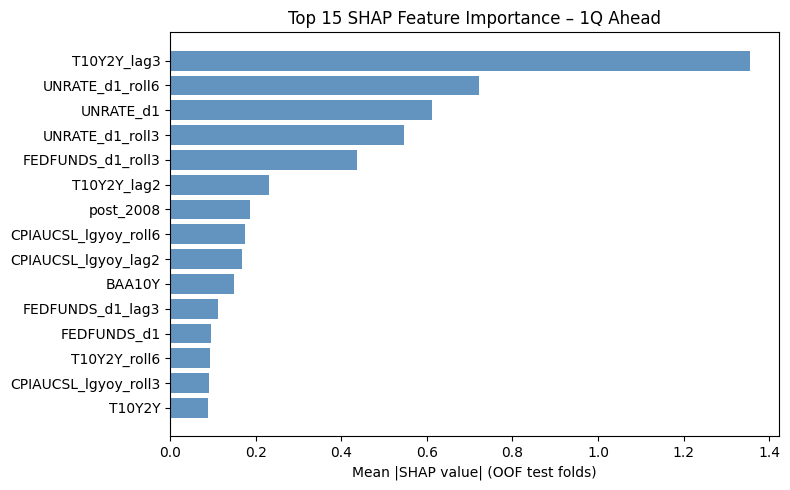

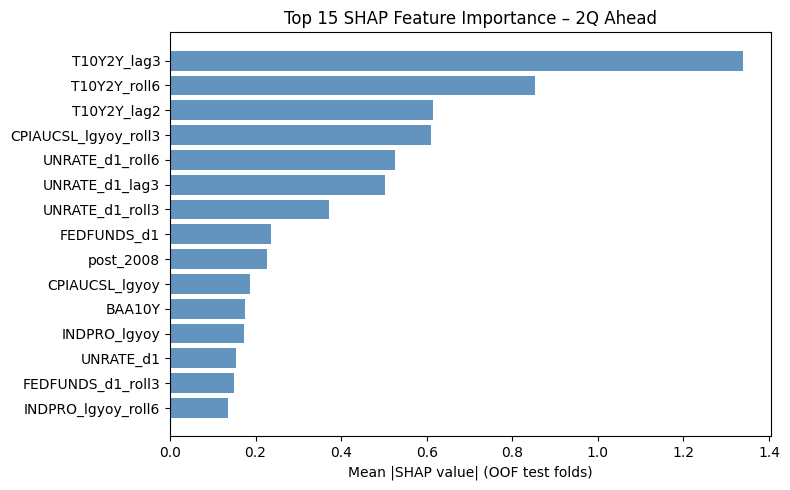

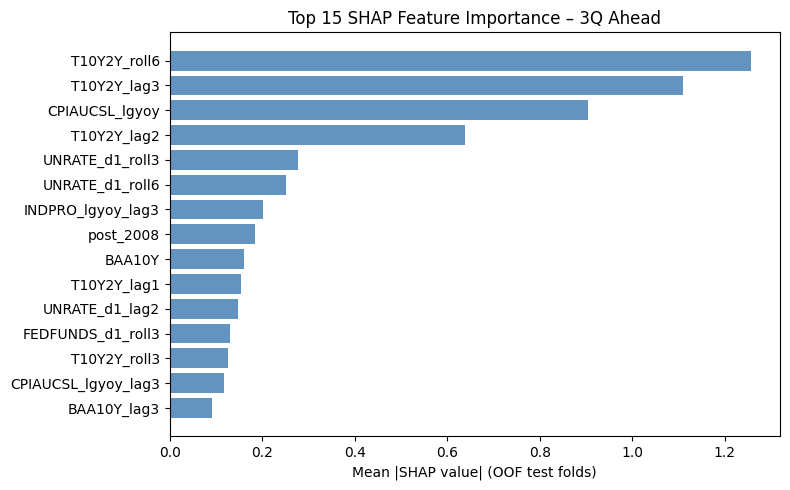

Top SHAP features for 1Q Ahead:


,mean_abs_shap
T10Y2Y_lag3,1.35589
UNRATE_d1_roll6,0.72187
UNRATE_d1,0.61134
UNRATE_d1_roll3,0.54671
FEDFUNDS_d1_roll3,0.43671
T10Y2Y_lag2,0.23030
post_2008,0.18661
CPIAUCSL_lgyoy_roll6,0.17490
CPIAUCSL_lgyoy_lag2,0.16870
BAA10Y,0.14883


In [15]:
shap_importance_tables = {}
for horizon in horizons:
    sv   = shap_store[(horizon, "xgb_tuned")]["values"]
    X_sh = shap_store[(horizon, "xgb_tuned")]["X"]
    mean_abs_shap = np.abs(sv).mean(axis=0)
    shap_table = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
    shap_importance_tables[horizon] = shap_table
    shap_table.to_csv(os.path.join(OUTDIR, f"{horizon}_shap_importance.csv"),
                      header=["mean_abs_shap"])
    label = horizon.replace("Target_", "").replace("_ahead", "")
    shap_tbl = shap_table.head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(shap_tbl.index[::-1], shap_tbl.values[::-1], color="steelblue", alpha=0.85)
    ax.set_xlabel("Mean |SHAP value| (OOF test folds)")
    ax.set_title(f"Top 15 SHAP Feature Importance – {label} Ahead")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_shap_bar.png"), dpi=150)
    plt.show()
print("Top SHAP features for 1Q Ahead:")
display(shap_importance_tables["Target_1Q_ahead"].head(15).to_frame("mean_abs_shap").round(5))

## 8.6 – SHAP Beeswarm Plots

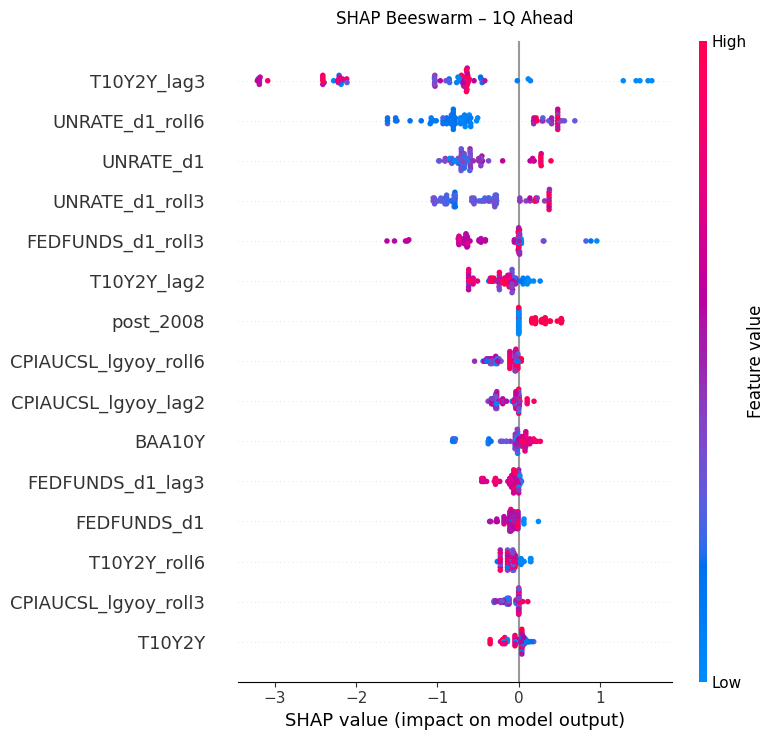

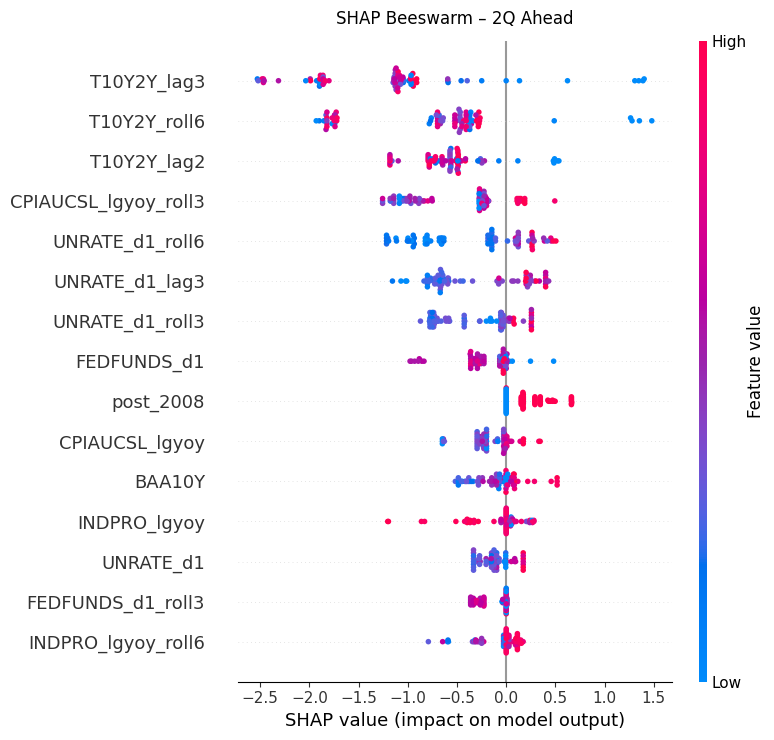

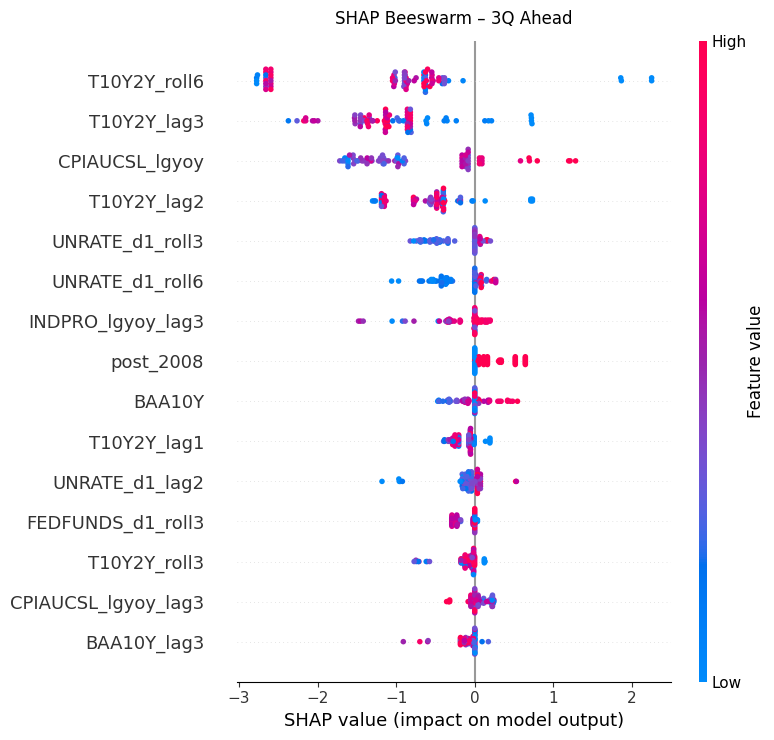

In [16]:
for horizon in horizons:
    label = horizon.replace("Target_", "").replace("_ahead", "")
    sv    = shap_store[(horizon, "xgb_tuned")]["values"]
    X_sh  = shap_store[(horizon, "xgb_tuned")]["X"]
    top15_idx = np.argsort(np.abs(sv).mean(axis=0))[::-1][:15]
    shap_exp  = shap.Explanation(
        values=sv[:, top15_idx],
        data=X_sh[:, top15_idx],
        feature_names=[feature_cols[i] for i in top15_idx],
    )
    plt.figure(figsize=(9, 6))
    shap.plots.beeswarm(shap_exp, max_display=15, show=False)
    plt.title(f"SHAP Beeswarm – {label} Ahead", pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_shap_beeswarm.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 8.7 – Hyperparameter Summary (XGBoost Tuned)

In [17]:
for horizon in horizons:
    label       = horizon.replace("Target_", "").replace("_ahead", "")
    fold_params = best_params_store[(horizon, "xgb_tuned")]
    param_df    = pd.DataFrame(fold_params)
    summary     = pd.DataFrame({"mode": param_df.mode().iloc[0], "mean": param_df.mean().round(4)})
    print(f"\nBest XGB hyperparameters — {label} Ahead:")
    display(summary)
    summary.to_csv(os.path.join(OUTDIR, f"{horizon}_best_params.csv"))


Best XGB hyperparameters — 1Q Ahead:


,mode,mean
colsample_bytree,0.80,0.800
learning_rate,0.05,0.055
max_depth,2.00,2.100
n_estimators,200.00,240.000
reg_alpha,0.10,0.370
reg_lambda,5.00,3.800
subsample,0.80,0.800



Best XGB hyperparameters — 2Q Ahead:


,mode,mean
colsample_bytree,0.80,0.80
learning_rate,0.05,0.06
max_depth,2.00,2.30
n_estimators,200.00,280.00
reg_alpha,0.10,0.28
reg_lambda,1.00,1.40
subsample,0.80,0.80



Best XGB hyperparameters — 3Q Ahead:


,mode,mean
colsample_bytree,0.80,0.800
learning_rate,0.05,0.055
max_depth,2.00,2.100
n_estimators,200.00,240.000
reg_alpha,0.10,0.190
reg_lambda,1.00,2.200
subsample,0.80,0.800


## 8.8 – Comparison vs Team A (Logistic Regression)

In [18]:
TEAM_A_PATH = os.path.join("model_team_a_outputs", "model_comparison.csv")
if os.path.exists(TEAM_A_PATH):
    team_a_df = pd.read_csv(TEAM_A_PATH)
    team_a_df["team"] = "Team_A (LogReg)"
    results_df["team"] = "Team_B (XGBoost+)"
    combined = pd.concat([team_a_df, results_df], ignore_index=True)
    combined = combined.sort_values(["horizon", "team", "model"])
    print("Combined Team A vs Team B metrics:")
    display(combined[["team", "model", "horizon", "auc",
                       "average_precision", "brier", "log_loss"]].round(4))
    combined.to_csv(os.path.join(OUTDIR, "combined_team_comparison.csv"), index=False)
else:
    print(f"Team A outputs not found at {TEAM_A_PATH}.")
    print("\nTeam B standalone results:")
    display(results_df.round(4))

Team A outputs not found at model_team_a_outputs/model_comparison.csv.

Team B standalone results:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,elastic_net,80,8,0.9670,0.6787,0.0587,0.4532
1,1Q,smote_xgb,80,8,0.8750,0.4279,0.0827,0.3207
2,1Q,stack_ensemble,56,8,0.9375,0.6072,0.0999,0.3775
3,1Q,xgb_default,80,8,0.8594,0.3905,0.0952,0.3426
4,1Q,xgb_tuned,80,8,0.8472,0.3926,0.0903,0.3158
5,2Q,elastic_net,80,8,0.9497,0.5736,0.0778,0.3062
6,2Q,smote_xgb,80,8,0.8264,0.3463,0.0898,0.3297
7,2Q,stack_ensemble,56,8,0.7865,0.3838,0.1471,0.4995
8,2Q,xgb_default,80,8,0.8264,0.3798,0.0923,0.3366
9,2Q,xgb_tuned,80,8,0.8490,0.3830,0.0914,0.3286


# 9 – Robustness Across Regimes

Tests whether model performance is stable across distinct macroeconomic eras or whether strong overall metrics are driven by fitting well to a single crisis episode.

**Four regimes defined:**
| Regime | Period | Key events |
|---|---|---|
| Pre-2000 | Before 2000-01-01 | Early expansion, 1990–91 recession |
| 2000–2007 | 2000-01-01 to 2007-12-31 | Dot-com bust, jobless recovery |
| 2008–2019 | 2008-01-01 to 2019-12-31 | GFC, long expansion |
| Post-2020 | 2020-01-01 onward | COVID shock, inflation surge |

**Overfitting signal:** A model is likely overfit to a crisis period if its AUC in that regime is ≥0.10 higher than its average across all other regimes.

**Note on reliability:** Regimes with fewer than 5 positive (recession) observations will produce unstable AUC estimates. Those cells are flagged with `*` in the output table.

## 9.1 – Regime Definitions

In [19]:
REGIMES = {
    "pre_2000":  (pd.Timestamp("1900-01-01"), pd.Timestamp("1999-12-31")),
    "2000_2007": (pd.Timestamp("2000-01-01"), pd.Timestamp("2007-12-31")),
    "2008_2019": (pd.Timestamp("2008-01-01"), pd.Timestamp("2019-12-31")),
    "post_2020": (pd.Timestamp("2020-01-01"), pd.Timestamp("2099-12-31")),
}

# Models to include in robustness analysis — focus on the meaningful ones
ROBUST_MODELS = ["elastic_net", "xgb_tuned", "smote_xgb", "stack_ensemble"]

MIN_POSITIVES = 5  # minimum recession quarters needed for a reliable AUC

print("Regime boundaries:")
for name, (start, end) in REGIMES.items():
    print(f"  {name:12s}  {start.date()} → {end.date()}")

Regime boundaries:
  pre_2000      1900-01-01 → 1999-12-31
  2000_2007     2000-01-01 → 2007-12-31
  2008_2019     2008-01-01 → 2019-12-31
  post_2020     2020-01-01 → 2099-12-31


## 9.2 – Per-Regime Metrics Computation

In [20]:
def regime_metrics(frame, start, end):
    """
    Compute AUC, AP, and Brier score for OOF predictions within a date window.
    Returns a dict with metrics and a reliability flag.
    """
    mask = (frame["Date"] >= start) & (frame["Date"] <= end)
    sub  = frame[mask]
    n_pos = int(sub["y_true"].sum())
    n_obs = len(sub)

    if n_obs < 8 or len(sub["y_true"].unique()) < 2:
        return {"auc": np.nan, "ap": np.nan, "brier": np.nan,
                "n_obs": n_obs, "n_pos": n_pos, "reliable": False}

    return {
        "auc":      roc_auc_score(sub["y_true"], sub["y_prob"]),
        "ap":       average_precision_score(sub["y_true"], sub["y_prob"]),
        "brier":    brier_score_loss(sub["y_true"], sub["y_prob"]),
        "n_obs":    n_obs,
        "n_pos":    n_pos,
        "reliable": n_pos >= MIN_POSITIVES,
    }


regime_rows = []

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    for mname in ROBUST_MODELS:
        if (horizon, mname) not in oof_store:
            continue
        frame = oof_store[(horizon, mname)]
        for regime, (r_start, r_end) in REGIMES.items():
            m = regime_metrics(frame, r_start, r_end)
            regime_rows.append({
                "horizon": h_label,
                "model":   mname,
                "regime":  regime,
                **m,
            })

regime_df = pd.DataFrame(regime_rows)

# Add reliability flag marker for display
regime_df["auc_display"] = regime_df.apply(
    lambda r: f"{r['auc']:.3f}" + ("" if r["reliable"] else " *"),
    axis=1
)

print("Raw regime metrics computed.")
print(f"  * = fewer than {MIN_POSITIVES} recession quarters in window (AUC unreliable)")
display(regime_df[["horizon", "model", "regime", "n_obs", "n_pos",
                    "auc", "ap", "brier", "reliable"]].round(4))

regime_df.to_csv(os.path.join(OUTDIR, "regime_robustness_raw.csv"), index=False)

Raw regime metrics computed.
  * = fewer than 5 recession quarters in window (AUC unreliable)


,horizon,model,regime,n_obs,n_pos,auc,ap,brier,reliable
0,1Q,elastic_net,pre_2000,0,0,NaN,NaN,NaN,False
1,1Q,elastic_net,2000_2007,23,1,1.0000,1.0000,0.0627,False
2,1Q,elastic_net,2008_2019,48,6,0.9960,0.9762,0.0241,True
3,1Q,elastic_net,post_2020,9,1,0.7500,0.3333,0.2329,False
4,1Q,xgb_tuned,pre_2000,0,0,NaN,NaN,NaN,False
5,1Q,xgb_tuned,2000_2007,23,1,1.0000,1.0000,0.0183,False
6,1Q,xgb_tuned,2008_2019,48,6,0.8730,0.7596,0.0956,True
7,1Q,xgb_tuned,post_2020,9,1,0.6250,0.2500,0.2465,False
8,1Q,smote_xgb,pre_2000,0,0,NaN,NaN,NaN,False
9,1Q,smote_xgb,2000_2007,23,1,1.0000,1.0000,0.0118,False


## 9.3 – AUC Heatmap by Regime × Model

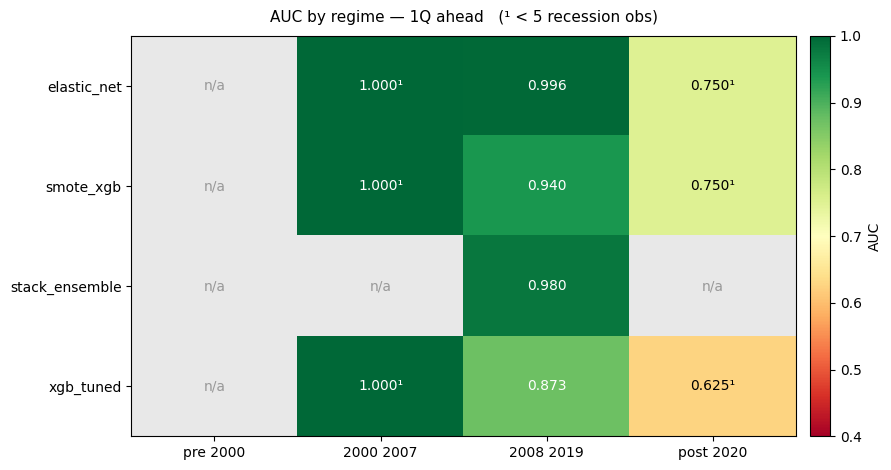

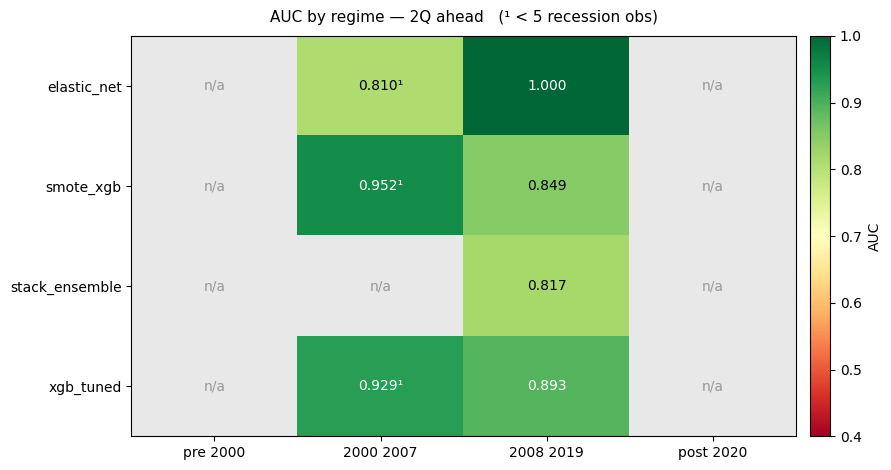

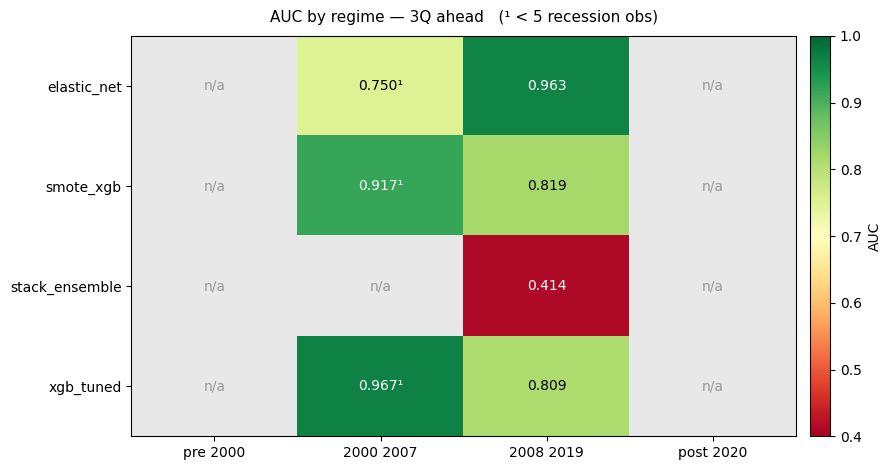

In [21]:
regime_order = ["pre_2000", "2000_2007", "2008_2019", "post_2020"]

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    sub = regime_df[regime_df["horizon"] == h_label].copy()

    pivot_auc = sub.pivot(index="model", columns="regime", values="auc")[regime_order]
    pivot_rel = sub.pivot(index="model", columns="regime", values="reliable")[regime_order]

    fig, ax = plt.subplots(figsize=(9, len(ROBUST_MODELS) * 0.9 + 1.2))

    # Draw heatmap manually for full control over NaN cells
    data_arr = pivot_auc.values.astype(float)
    rel_arr  = pivot_rel.values

    # Use a masked array so NaN cells don't affect the colorscale
    masked = np.ma.masked_invalid(data_arr)
    cmap = plt.cm.RdYlGn
    cmap.set_bad(color="#e8e8e8")
    im = ax.imshow(masked, cmap=cmap, vmin=0.4, vmax=1.0, aspect="auto")

    # Annotate each cell
    for i in range(data_arr.shape[0]):
        for j in range(data_arr.shape[1]):
            val = data_arr[i, j]
            if np.isnan(val):
                txt = "n/a"
                color = "#999"
            else:
                reliable = bool(rel_arr[i, j]) if rel_arr[i, j] is not None else False
                txt = f"{val:.3f}" + ("" if reliable else "\u00b9")
                color = "white" if val < 0.6 or val > 0.85 else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=10,
                    color=color, fontweight="normal")

    ax.set_xticks(range(len(regime_order)))
    ax.set_xticklabels([r.replace("_", " ") for r in regime_order], fontsize=10)
    ax.set_yticks(range(len(pivot_auc.index)))
    ax.set_yticklabels(pivot_auc.index, fontsize=10)
    ax.set_title(f"AUC by regime — {h_label} ahead   (¹ < {MIN_POSITIVES} recession obs)",
                 fontsize=11, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="AUC")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_auc_heatmap.png"), dpi=150)
    plt.show()

## 9.4 – AUC Variance Across Regimes (Stability Score)

A model with low AUC variance across regimes is more robust. We compute the standard deviation of AUC across all reliable regimes — lower is better.

In [22]:
stability_rows = []

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    sub = regime_df[(regime_df["horizon"] == h_label) & (regime_df["reliable"] == True)]

    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname]["auc"].dropna()
        if len(m_sub) < 2:
            continue
        stability_rows.append({
            "horizon":    h_label,
            "model":      mname,
            "mean_auc":   m_sub.mean(),
            "std_auc":    m_sub.std(),
            "min_auc":    m_sub.min(),
            "max_auc":    m_sub.max(),
            "auc_range":  m_sub.max() - m_sub.min(),
            "n_regimes":  len(m_sub),
        })

stability_df = pd.DataFrame(stability_rows).sort_values(["horizon", "std_auc"])

print("Regime stability scores (reliable regimes only, lower std = more stable):")
display(stability_df.round(4))
stability_df.to_csv(os.path.join(OUTDIR, "regime_stability_scores.csv"), index=False)

KeyError: 'horizon'

## 9.5 – Overfitting Flag: Crisis-Period Detection

A model is flagged as potentially overfit to a crisis period if its AUC in that regime exceeds the mean of all other reliable regimes by more than `OVERFIT_THRESHOLD`.

In [23]:
OVERFIT_THRESHOLD = 0.10  # AUC uplift vs other regimes to trigger flag

overfit_flags = []

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    sub = regime_df[(regime_df["horizon"] == h_label) & (regime_df["reliable"] == True)]

    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname][["regime", "auc"]].dropna()
        if len(m_sub) < 3:
            continue
        for _, row in m_sub.iterrows():
            others_mean = m_sub[m_sub["regime"] != row["regime"]]["auc"].mean()
            uplift = row["auc"] - others_mean
            if uplift >= OVERFIT_THRESHOLD:
                overfit_flags.append({
                    "horizon":     h_label,
                    "model":       mname,
                    "regime":      row["regime"],
                    "regime_auc":  row["auc"],
                    "others_mean": others_mean,
                    "uplift":      uplift,
                })

if overfit_flags:
    flags_df = pd.DataFrame(overfit_flags).sort_values("uplift", ascending=False)
    print(f"Overfitting flags (AUC uplift >= {OVERFIT_THRESHOLD} vs other regimes):")
    display(flags_df.round(4))
    flags_df.to_csv(os.path.join(OUTDIR, "overfit_flags.csv"), index=False)
else:
    print(f"No overfitting flags detected at threshold={OVERFIT_THRESHOLD}.")
    print("All models show broadly consistent performance across regimes.")

No overfitting flags detected at threshold=0.1.
All models show broadly consistent performance across regimes.


## 9.6 – Per-Regime AUC Line Plot

Shows how each model's discriminative power evolves across regimes. Flat lines indicate regime-robust models; steep drops signal fragility.

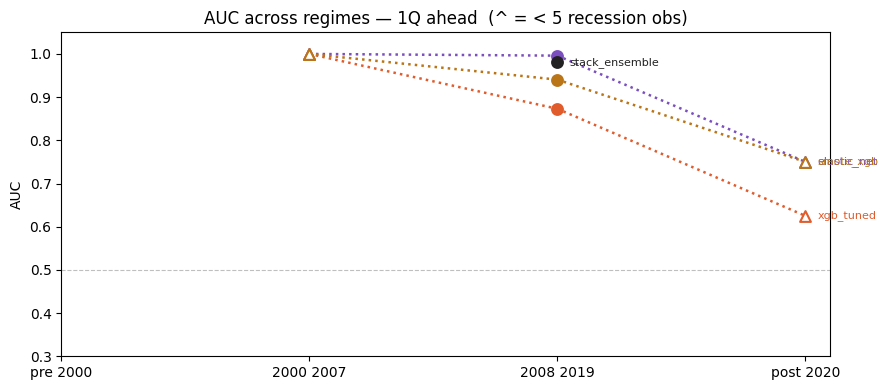

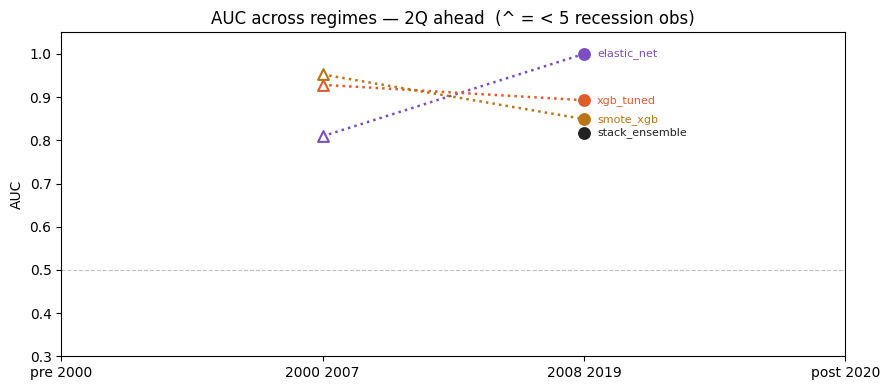

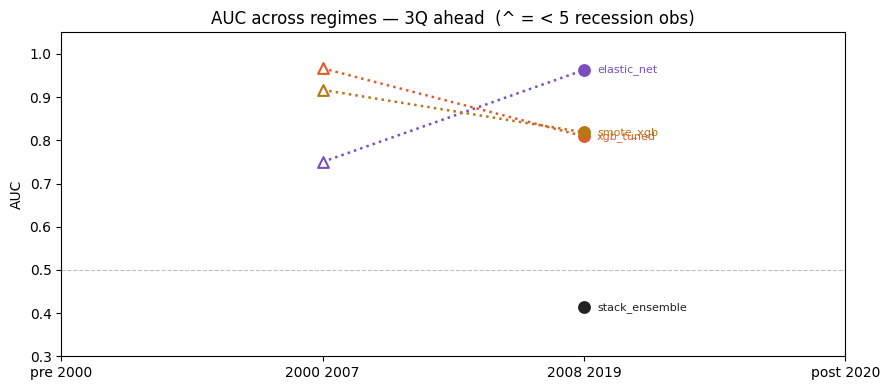

In [24]:
ROBUST_COLORS = {
    "elastic_net":    "#7B4FBF",
    "xgb_tuned":      "#e05c2d",
    "smote_xgb":      "#BA7517",
    "stack_ensemble": "#222222",
}

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    sub = regime_df[regime_df["horizon"] == h_label]

    fig, ax = plt.subplots(figsize=(9, 4))
    x_pos = range(len(regime_order))

    for mname in ROBUST_MODELS:
        m_sub = sub[sub["model"] == mname].set_index("regime").reindex(regime_order)
        aucs      = m_sub["auc"].values
        reliable  = m_sub["reliable"].values
        color     = ROBUST_COLORS.get(mname, "gray")

        # Solid line for reliable regimes, dashed for unreliable
        for i in range(len(regime_order) - 1):
            if np.isnan(aucs[i]) or np.isnan(aucs[i + 1]):
                continue
            ls = "-" if (reliable[i] and reliable[i + 1]) else ":"
            ax.plot([i, i + 1], [aucs[i], aucs[i + 1]],
                    color=color, lw=1.8, ls=ls)

        # Markers: filled = reliable, open = unreliable
        for i, (auc_val, rel) in enumerate(zip(aucs, reliable)):
            if np.isnan(auc_val):
                continue
            marker = "o" if rel else "^"
            fc = color if rel else "white"
            ax.scatter(i, auc_val, color=color, s=60, zorder=5,
                       marker=marker, facecolors=fc, edgecolors=color, lw=1.5)

        # Label the last valid point
        last_valid = [(i, v) for i, v in enumerate(aucs) if not np.isnan(v)]
        if last_valid:
            li, lv = last_valid[-1]
            ax.text(li + 0.05, lv, mname, fontsize=8, color=color, va="center")

    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5, label="Random (0.5)")
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([r.replace("_", " ") for r in regime_order], fontsize=10)
    ax.set_ylabel("AUC")
    ax.set_ylim(0.3, 1.05)
    ax.set_title(f"AUC across regimes — {h_label} ahead  (^ = < {MIN_POSITIVES} recession obs)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_auc_lineplot.png"), dpi=150)
    plt.show()

## 9.7 – Brier Score by Regime

Brier score measures calibration quality within each regime. A spike in a specific period reveals the model is generating poorly calibrated probabilities there even when AUC looks acceptable.

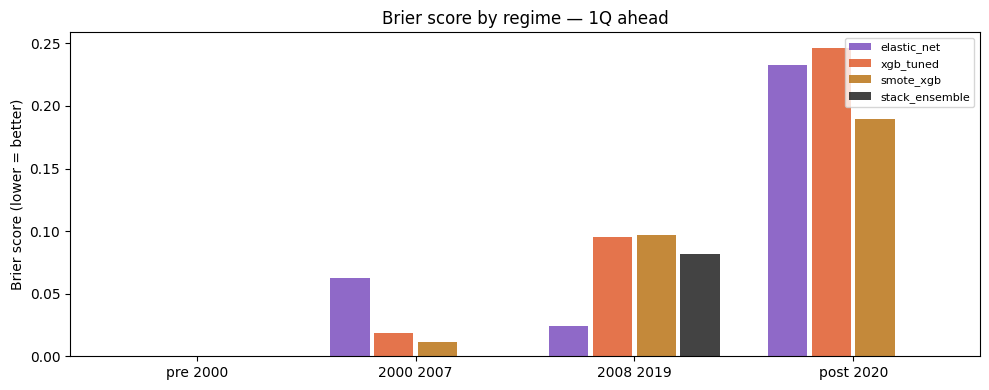

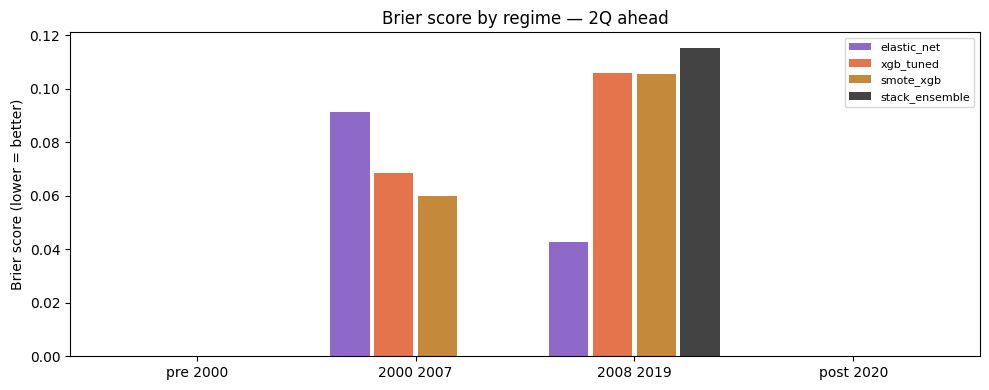

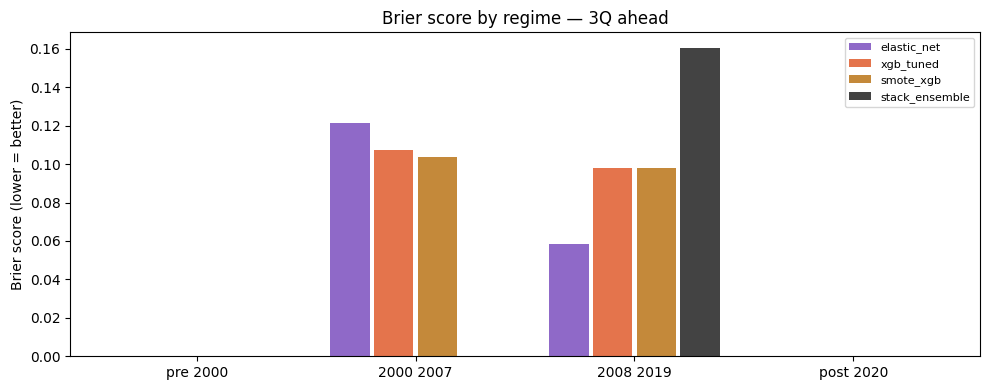

In [25]:
for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    sub = regime_df[regime_df["horizon"] == h_label]

    pivot_brier = sub.pivot(index="model", columns="regime", values="brier")[regime_order]
    pivot_brier = pivot_brier.reindex(ROBUST_MODELS).dropna(how="all")

    x = np.arange(len(regime_order))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 4))

    for i, mname in enumerate(pivot_brier.index):
        vals = pivot_brier.loc[mname].values.astype(float)
        color = ROBUST_COLORS.get(mname, "gray")
        offset = (i - len(pivot_brier.index) / 2 + 0.5) * width
        bars = ax.bar(x + offset, np.where(np.isnan(vals), 0, vals),
                      width=width * 0.9, color=color, alpha=0.85, label=mname)

    ax.set_xticks(x)
    ax.set_xticklabels([r.replace("_", " ") for r in regime_order], fontsize=10)
    ax.set_ylabel("Brier score (lower = better)")
    ax.set_title(f"Brier score by regime — {h_label} ahead")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_regime_brier_bars.png"), dpi=150)
    plt.show()

## 9.8 – Regime Robustness Summary Table

In [26]:
print("="*70)
print("REGIME ROBUSTNESS SUMMARY")
print("="*70)

for horizon in horizons:
    h_label = horizon.replace("Target_", "").replace("_ahead", "")
    print(f"\n--- {h_label} ahead ---")

    sub_stab = stability_df[stability_df["horizon"] == h_label]
    if sub_stab.empty:
        print("  Insufficient data for stability analysis.")
        continue

    # Most stable model
    most_stable = sub_stab.sort_values("std_auc").iloc[0]
    print(f"  Most stable model:  {most_stable['model']}  "
          f"(AUC std={most_stable['std_auc']:.3f}, "
          f"range={most_stable['auc_range']:.3f})")

    # Highest mean AUC across regimes
    best_mean = sub_stab.sort_values("mean_auc", ascending=False).iloc[0]
    print(f"  Best mean AUC:      {best_mean['model']}  "
          f"(mean={best_mean['mean_auc']:.3f})")

    # Any overfit flags for this horizon
    if overfit_flags:
        h_flags = [f for f in overfit_flags if f["horizon"] == h_label]
        if h_flags:
            print(f"  Overfit flags ({len(h_flags)}):")
            for f in h_flags:
                print(f"    {f['model']:20s} in {f['regime']:12s}  "
                      f"uplift={f['uplift']:.3f}")
        else:
            print("  No overfit flags.")

print("\nFull tables saved to:", OUTDIR)

REGIME ROBUSTNESS SUMMARY

--- 1Q ahead ---


NameError: name 'stability_df' is not defined

---

## Notes for the Report

### Model summary
| Model | Key strength | Watch out for |
|---|---|---|
| `xgb_tuned` | Non-linear threshold effects | Calibration, class imbalance sensitivity |
| `xgb_default` | Fast baseline | No tuning, sub-optimal AP |
| `elastic_net` | Stable with correlated lags (yield curve) | Slightly slower than L1 alone |
| `smote_xgb` | Richer minority-class decision boundary | Synthetic points may be unrealistic |
| `stack_ensemble` | Combines complementary errors from all base models | Fewer OOF points for meta-training (initial=20) |

### Reporting guidance — Robustness section
- **Lead with the stability score** (§9.4). A model with AUC std < 0.05 across regimes is credibly robust; one with std > 0.15 should be treated with caution regardless of overall AUC.
- **The post-2020 regime is high-risk for overfitting.** COVID-19 generated an extremely sharp, short recession (2020Q1–Q2) with a rapid recovery — models that score very high there may be detecting the unique velocity of the shock, not a generalizable recession signal.
- **The pre-2000 regime often has few recession observations** (depending on dataset start date). Any AUC flagged with `¹` should be cited as indicative only.
- **Brier score spikes** (§9.7) in a specific regime, even without an AUC drop, indicate the model is producing overconfident or underconfident probabilities in that era — relevant if the model is used for decision-making with probability thresholds.
- **Cross-reference with SHAP values**: if a model is flagged as overfit to 2008–2019, check whether GFC-era features (BAA10Y, FEDFUNDS_d1 lags) dominate SHAP at the expense of pre-2000 leading indicators.
